# Práctica 2: Obteniendo máximos y mínimos en dos dimensiones con distintos métodos

El objetivo de esta práctica es calcular máximos en $2$ dimensiones con los métodos de máxima pendiente y del gradiente conjugado.

Para ello, vamos a analizar los datos del fichero **data_practica_2.txt**, que podéis encontrar en el **apartado de la Práctica 2 del Campus Virtual**. Éstos proporcionan la altura de unas montañas contenidas en el plano $(𝑥,𝑦)$ definido por $-3\leq x \leq 3$, $-3\leq y \leq 3$, en un grid $121\times 121$ de puntos equiespaciados.

1. **[2 pts]** Importar y representar el fichero de datos en $3$ dimensiones, y también en $2$ dimensiones con **imshow**. 

   **Ayuda:** 
   - Para representar en 3 dimensiones, se recomienda importar **subplots** de **matplotlib.pyplot**, y escribir las siguientes líneas
   ***
       fig, ax = subplots(subplot_kw={"projection": "3d"})
   
       ax.plot_surface(data_x,data_y,data_z, cmap='patron')
   ***
   - **data_x** y **data_y** han de ser arrays de dos dimensiones, con las coordenadas $x$ e $y$ del grid, respectivamente. Para obtenerlos, se recomienda el uso de **meshgrid**.
   
   - Se recomienda utilizar el patrón de color **terrain** de **imshow**.

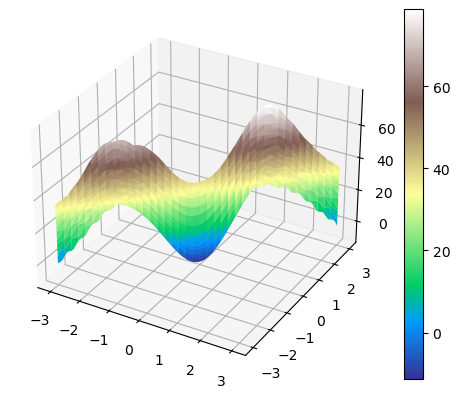

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Z = np.loadtxt("data_practica_2.txt")

t = np.linspace(-3,3,121)
X, Y = np.meshgrid(t, t)

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
p = ax.plot_surface(t, t, Z, cmap="terrain")
fig.colorbar(p)
plt.show()

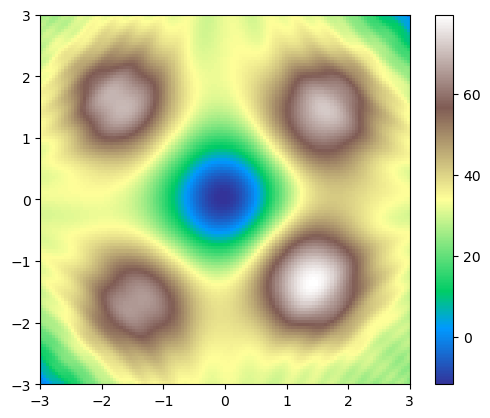

In [2]:
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.show()

2. **[0.5 pts]** Definir una función interpoladora de los puntos del fichero por medio de splines cúbicos. Para ello, hacer uso de la función **RectBivariateSpline** de **scipy.interpolate** de la siguiente forma:

***
        f = RectBivariateSpline(x,y, data_z.T)
***
donde $x$ e $y$ son **arrays de $1$ una dimensión** con las coordenadas cartesianas que definen el grid (no la cuadrícula, solo los ejes).

In [3]:
from scipy.interpolate import RectBivariateSpline

f = RectBivariateSpline(t, t, Z.T)

3. **[1 pt]** Realizar la representación de densidad de la función del apartado anterior en $-3\leq x\leq 3$, $-3 \leq y\leq 3$ en un grid $1000\times 1000$. Además, elegir un punto inicial para calcular el máximo global en dicho dominio, y añadirlo a la representación.

   **Ayuda:** 
   - En el **imshow**, basta introducir 
       ***
           f(x',y').T
       ***
       donde x' e y' son los arrays creados para la representación (no hay que usar **meshgrid**).
   - Se recomienda utilizar en **imshow** la opción **extent** para representar con facilidad el punto inicial escogido.

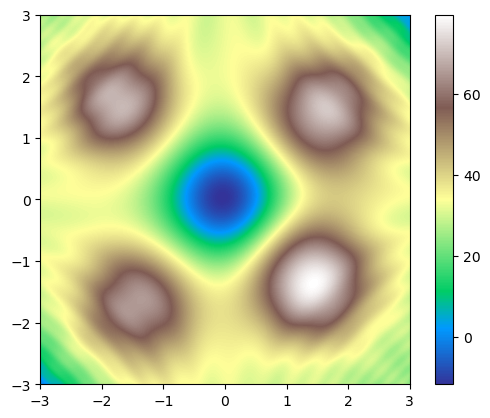

In [4]:
t = np.linspace(-3,3,1000)
Z = f(t, t).T
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.show()

Punto seleccionado: $(1.5, -1.5)$

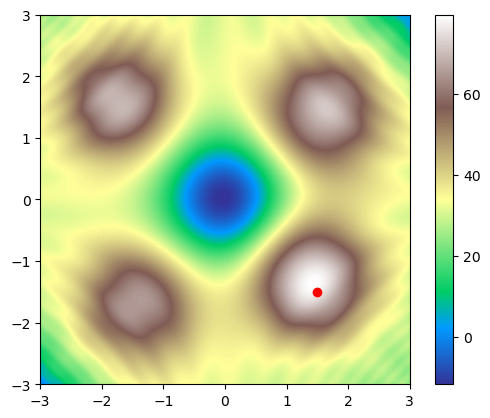

In [5]:
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.plot(1.5, -1.5, "ro")
plt.show()

4. **[4 pts]** Implementar el método de máxima pendiente para funciones de dos variables con el fin de encontrar un máximo con una precisión de $10^{-5}$. El cálculo del gradiente deberá hacerse con diferencias centradas, con paso $h=10^{-3}$ para ambas variables, y utilizar el método de la razón áurea para la maximización en una variable. ¿Por qué es preferible al método de Gauss-Newton?

In [6]:
def razon_aurea(f, x1, x4, tol):
    z = (1+np.sqrt(5))/2
    
    x2 = x4 - (x4-x1)/z
    x3 = x1 + (x4-x1)/z
    
    err = 1.0
    
    while err > tol:
        if f(x2) < f(x3): # Vamos en el buen camino si vamos hacia la izq.
            x4 = x3
            x3 = x2
            x2 = x4 - (x4-x1)/z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4-x1)/z
        err = np.abs(x4-x1)
    return (x1+x4)/2

In [21]:
import numpy as np

def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-3)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x[0][0], der_y[0][0]])

def max_pendiente(X0, tol):
    err = 1.0
    cont=0
    while err > tol:
        cont+=1
        v = grad(f, X0) # Dir de mínima pendiente hacia abajo para hallar el mínimo
        # Ahora avanzo un paso en esta dirección

        X1 = lambda alpha: X0+alpha*v.T

        err = lambda alpha: np.linalg.norm(X1(alpha)-X0)
        
        alpha_opt = razon_aurea(err, 10**(-2),1,10**(-5)) # cogemos el alpha que minimiza el error
        
        X1, err = X1(alpha_opt), err(alpha_opt)

        X0=X1

    return X1, cont

t = np.linspace(-3,3,121)
Z = f(t, t).T

pt_max, cont = max_pendiente([1.5, -1.5], 10**(-5))
print(pt_max)
#print(cont)

[ 1.43831043 -1.3714266 ]


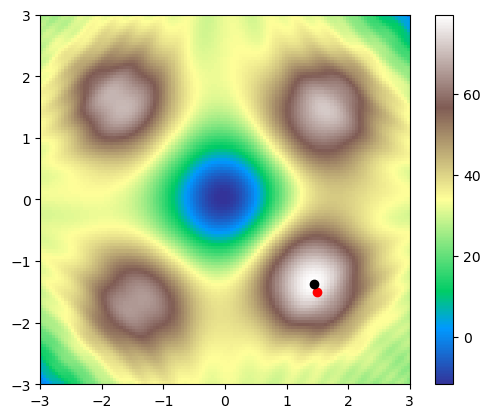

In [8]:
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.plot(1.5, -1.5, "ro")
plt.plot(pt_max[0], pt_max[1], "ko")
plt.show()

5. **[1,5 pts]** Aplicar el método de la máxima pendiente a la función definida en el apartado 2 para obtener su máximo global en $-3\leq x\leq 3$, $-3 \leq y\leq 3$. Añadir a la representación de densidad del apartado 3 las iteraciones que se han obtenido (para ello, puede modificarse levemente la función del apartado anterior).

   **Ayuda:** Por el funcionamiento de **RectBivariateSpline**, al evaluar la función interpoladora $f$ en un punto, se nos proporciona la evaluación de la función dentro de un array. Por ello se recomienda definir una función que evaluada en un punto $(x,y)$, devuelva $f(x,y)[0][0]$, y maximizar dicha función.

Hecho

6. **[1 pt]** Repetir el apartado anterior con otros puntos iniciales para obtener los otros máximos relativos. ¿Qué pasa si se coge como punto inicial el origen?¿Y si nos desplazamos de él un poco?

In [9]:
pt_max, cont = max_pendiente([1.5, 1.5], 10**(-5))
print(cont)

58


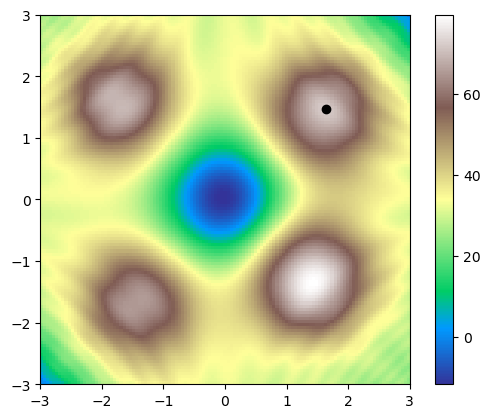

In [10]:
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.plot(pt_max[0], pt_max[1], "ko")
plt.show()

In [11]:
pt_max, cont = max_pendiente([-1.5, 1.5], 10**(-5))
print(cont)

6


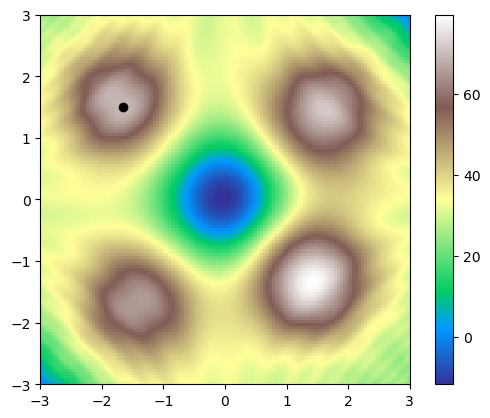

In [12]:
plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.plot(pt_max[0], pt_max[1], "ko")
plt.show()

28


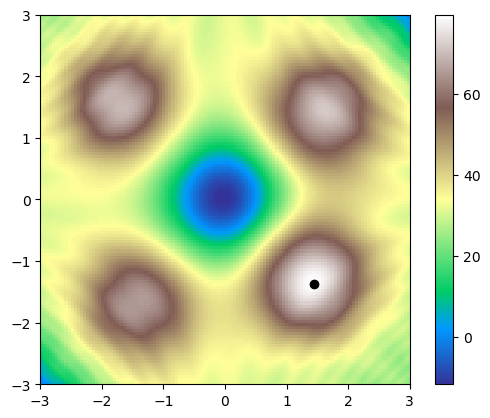

In [13]:
# Empezando desde el centro:

pt_max, cont = max_pendiente([0,0], 10**(-5))
print(cont)

plt.imshow(Z, origin="lower", extent=[-3,3,-3,3], cmap="terrain")
plt.colorbar()
plt.plot(pt_max[0], pt_max[1], "ko")
plt.show() # Se alcanza el máximo más escarpado, que en este caso coincide con el global.
# Si hubiésemos empleado Gauss-Newton, el método habría fallado al empezar desde un extremo porque el plano
# tangente a la superficie estaría recto

7. **[Extra]** Implementar el método del gradiente conjugado, y aplicarlo a la función de apartado 2 para los mismos puntos iniciales. Añadir a la representación del apartado 3 las iteraciones obtenidas. ¿Qué diferencias observas respecto al método de la máxima pendiente?

In [49]:
import numpy as np

def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-3)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x[0][0], der_y[0][0]])


def grad_conj(X0, tol): # Si quieres MÁXIMO, le cambias el signo
    cont=0
    err = 1.0
    
    alpha=0.01
    D = grad(f, X0)

    while err > tol:
        cont+=1
        X1 = X0+alpha*D

        err = np.linalg.norm(X1-X0)
        
        grad_0 = grad(f, X0)
        grad_1 = grad(f, X1)
        
        beta = np.linalg.norm(grad_1)/np.linalg.norm(grad_0) # Solo sirve para calcular la nueva dirección a partir de la anterior
        
        D = grad_1+beta*D
        
        X0=X1
    print(cont)
    return X1

grad_conj([1.5, -1.5], 10**(-5))

40


array([ 1.43830762, -1.37143577])